# Autoencoder
### TODO
- [X] Autoencoder
- [ ] Denoising Autoencoder
- [ ] Variational Autoencoder

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm

from torch import sigmoid, tanh, cat
from torch.optim import RMSprop, Adam, SGD, Adagrad

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['figure.dpi'] = 100

<img src="https://upload.wikimedia.org/wikipedia/commons/3/37/Autoencoder_schema.png"  width="400" height="200">

# Define Autoencoder Module

In [64]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_layer = nn.Linear(784, 14*14)
        self.dec_layer = nn.Linear(14*14, 784)
        
    def forward(self, x):
        x = sigmoid(self.enc_layer(x))
        x = sigmoid(self.dec_layer(x))
        return x

# Prepare data

In [89]:
from torchvision.datasets import FashionMNIST
PATH = "/Users/kairos/fun/build2understand/autoencoder/"
mnist = FashionMNIST(root=PATH, download=True)
mnist.data = mnist.data.div(255)
mnist.data = mnist.data.reshape((60000, 784))

# Train model

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch: 0
Loss:1510.0028076171875


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch: 1
Loss:1442.7935791015625


...

Epoch: 27
Loss:1394.5140380859375


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch: 28
Loss:1300.64892578125


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch: 29
Loss:1365.23681640625
Final loss: 1365.23681640625


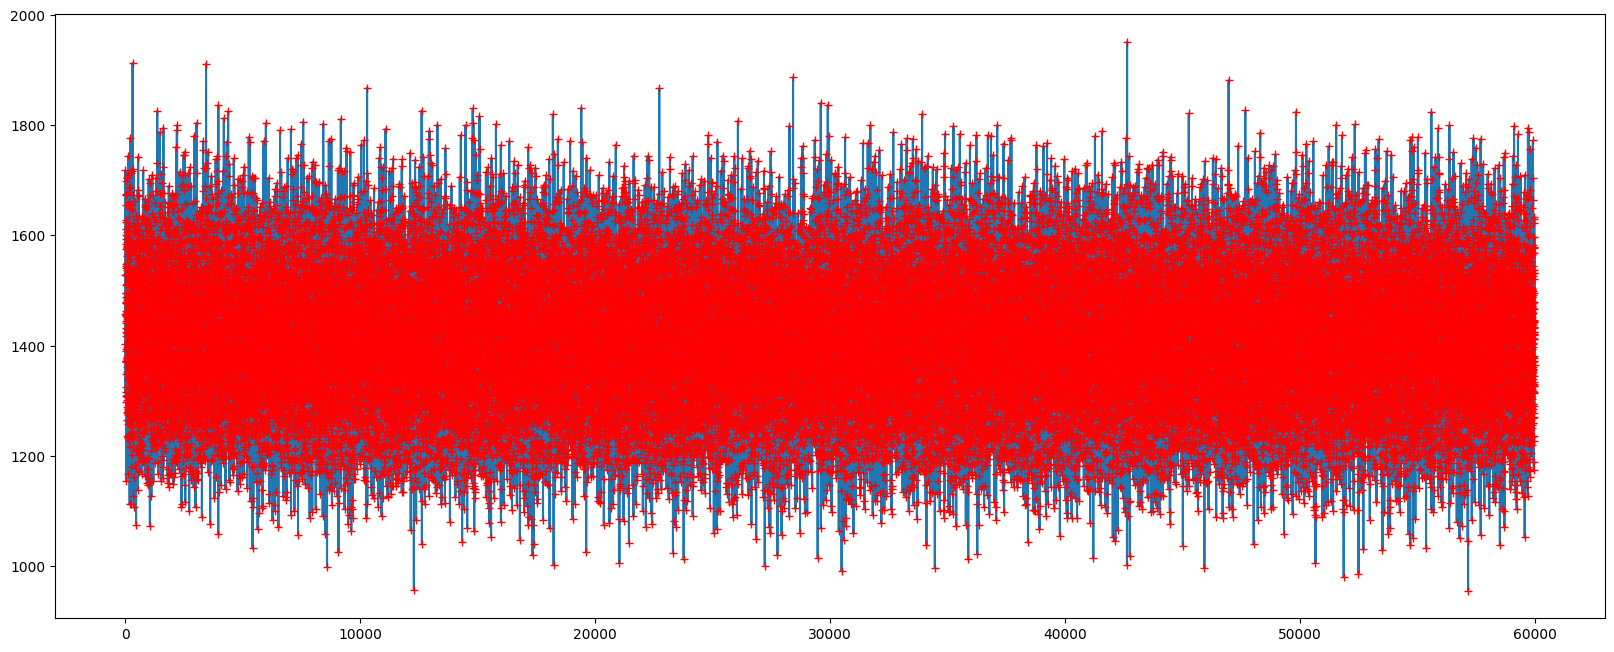

In [84]:
AE = Autoencoder()

optim = Adam(AE.parameters())
loss_fn = nn.CrossEntropyLoss(reduction='mean')
losses = []
EPOCHS = 30

for epoch in tqdm(range(EPOCHS)):
    data = mnist.data
    data = data[torch.randperm(data.size()[0])]
    mini_batches = data.reshape((2000, 30, 784))
    for batch_idx in tqdm(range(mini_batches.shape[0])):
        optim.zero_grad()
        
        x = mini_batches[batch_idx]
        pred = AE(x)
        loss = loss_fn(pred, x)
        loss.backward()
        optim.step()
        losses.append(loss.item())
    print(f"Epoch: {epoch}\nLoss:{losses[-1]}")


print(f"Final loss: {loss.item()}")
plt.plot(losses, '-+', mec='r')
plt.show()

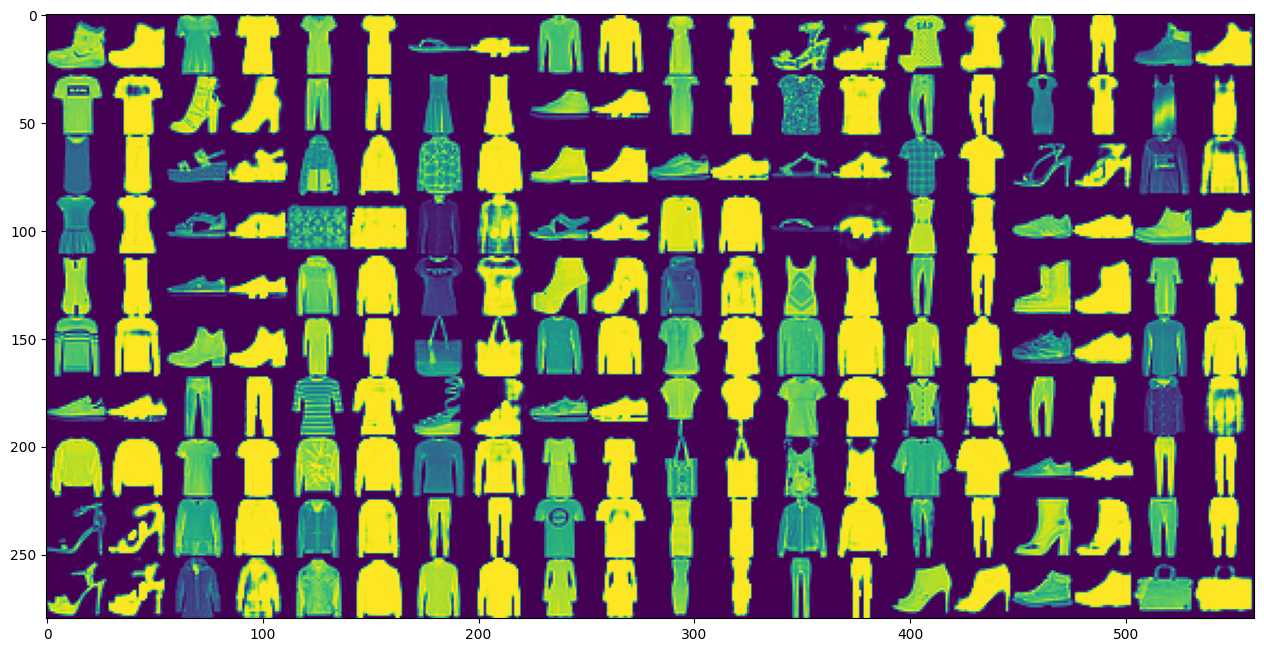

In [79]:
def construct_concatenated_image(real, model):
    final_img = cat((real[0], model(real[0].flatten()).reshape((28, 28))), 1)
    for i, re in enumerate(real[1:]):
        s = cat((re, model(real[i+1].flatten()).reshape((28, 28))), 1)
        final_img = cat((final_img, s), 0)
    return final_img

img = construct_concatenated_image(mnist.data.reshape((60000, 28, 28))[:10], AE)
for i in range(2, 11):
    new_col = construct_concatenated_image(mnist.data.reshape((60000, 28, 28))[(i-1)*10:i*10], AE)
    img = cat((img, new_col), 1)

imshow(img.detach().numpy())
plt.show()

# Cluster visualization using t-SNE

In [4]:
from sklearn.manifold import TSNE

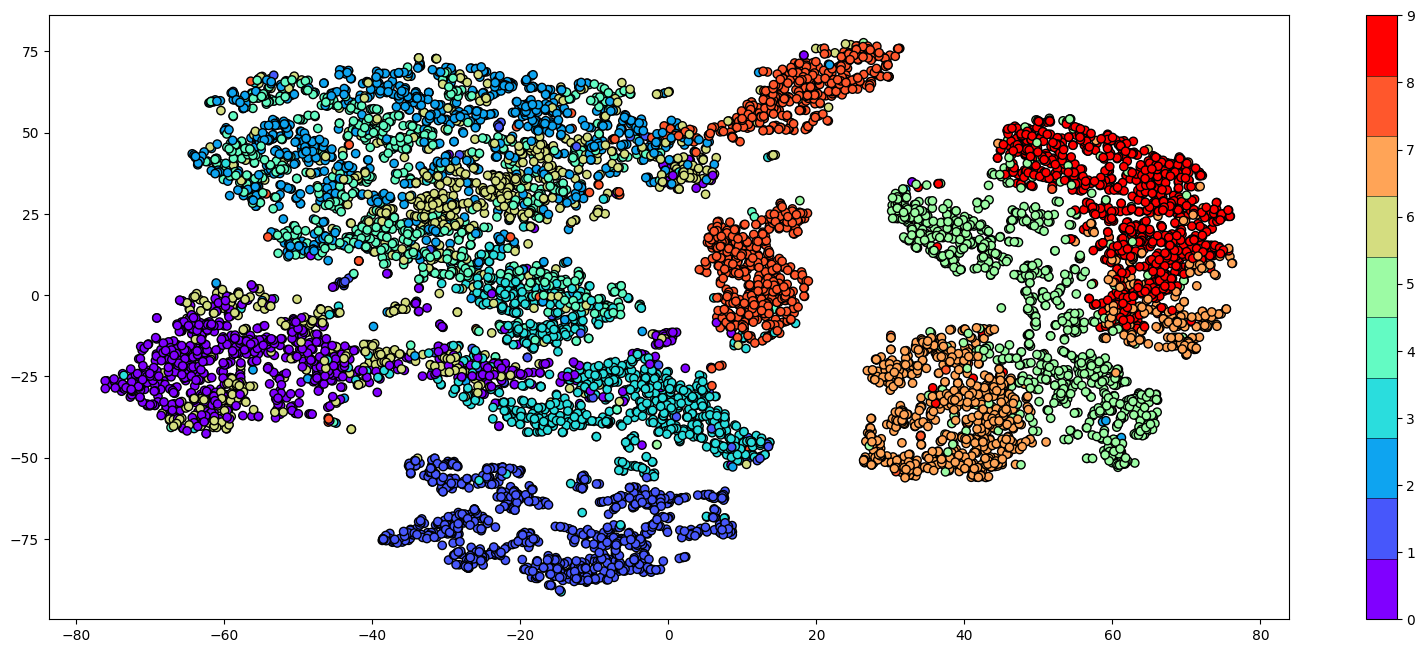

In [95]:
n_predict = 10000
x_encoded_TSNE = TSNE().fit_transform(AE(mnist.data[:n_predict]).detach().numpy())

cmap = plt.get_cmap('rainbow', 10)
plt.scatter(x_encoded_TSNE[:,0], x_encoded_TSNE[:,1], 
                c=mnist.targets[:n_predict], edgecolor='black', cmap=cmap)
plt.colorbar(drawedges=True)
plt.show()